In [39]:
import os
import sys
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)

from utils.paths import DESPIKED_DATA_DIRECTORY
from utils.import_data import import_acropolis_site_data
from config.sites_deloyment_times import deployment_times

assert(os.path.exists(DESPIKED_DATA_DIRECTORY))


### Overall strategy:
1. Choose a calibration frequency step.
2. Try all possible offsets for that frequency.
3. Apply sparse calibration points.
4. Interpolate slope and intercept.
5. Correct the GMP343 signal.
6. Compare against the reference (all calibration days) using RMSE / MAE.
7. Average performance across offsets.

In [40]:
# Filter calibration frequency data to only include every other row to module frequency
def filter_calibration_frequency(df_cal_times: pl.DataFrame, frequency: int, offset: int = 0) -> pl.DataFrame:
    assert frequency > 0, "Frequency must be a positive integer"
    assert offset >= 0, "Offset must be a non-negative integer"
    assert offset < frequency, "Offset must be less than frequency"
    
    return df_cal_times.with_row_index("idx") \
        .filter(pl.col("idx") % frequency == offset) \
        .drop("idx")

# v1

In [41]:
# define UTC timezones to filter the data to the time range of interest
start_time =  datetime(2025, 2, 18, 1, 0, 0).astimezone(timezone.utc)
end_time = datetime(2025, 10, 31, 0, 0, 0).astimezone(timezone.utc)

df_site = import_acropolis_site_data(target_directory=DESPIKED_DATA_DIRECTORY,
                                            deployment_times=deployment_times,
                                            site_name="TUMR") \
    .filter(pl.col("datetime").is_between(start_time, end_time))

# create a copy of the data to have a reference to compare to
df_reference = df_site.select(pl.col("datetime"), pl.col("gmp343_corrected"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U") \
    .group_by_dynamic("datetime", every="1h") \
    .agg(pl.col("gmp343_corrected").mean().alias("ref_corrected"))
    
# filter for slope, intercept; filter by first appearance of each unique value
df_cal_times = df_site.select(pl.col("datetime"), pl.col("slope"), pl.col("intercept")) \
    .unique(subset=["slope", "intercept"],keep="first",maintain_order=True)
    
# extract relevant data columns
df_data = df_site.select(pl.col("datetime"), pl.col("gmp343_dry"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U")

shape: (20, 7)
┌───────────┬───────────┬──────────┬───────────┬──────────┬──────────┬──────────┐
│ frequency ┆ rmse_mean ┆ rmse_std ┆ rmse_var  ┆ mae_mean ┆ mae_std  ┆ mae_var  │
│ ---       ┆ ---       ┆ ---      ┆ ---       ┆ ---      ┆ ---      ┆ ---      │
│ i64       ┆ f64       ┆ f64      ┆ f64       ┆ f64      ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪══════════╪═══════════╪══════════╪══════════╪══════════╡
│ 1         ┆ 0.931827  ┆ null     ┆ null      ┆ 0.499561 ┆ null     ┆ null     │
│ 2         ┆ 4.088297  ┆ 4.347606 ┆ 18.901676 ┆ 1.552419 ┆ 1.316822 ┆ 1.73402  │
│ 3         ┆ 3.204749  ┆ 3.402912 ┆ 11.579809 ┆ 1.380396 ┆ 0.897796 ┆ 0.806038 │
│ 4         ┆ 4.321689  ┆ 6.215961 ┆ 38.638177 ┆ 2.40422  ┆ 3.123391 ┆ 9.755572 │
│ 5         ┆ 2.493806  ┆ 2.234691 ┆ 4.993844  ┆ 1.334994 ┆ 0.522786 ┆ 0.273305 │
│ …         ┆ …         ┆ …        ┆ …         ┆ …        ┆ …        ┆ …        │
│ 16        ┆ 4.249391  ┆ 4.177895 ┆ 17.454807 ┆ 3.215833 ┆ 2.783323 ┆ 7.746887 │
│

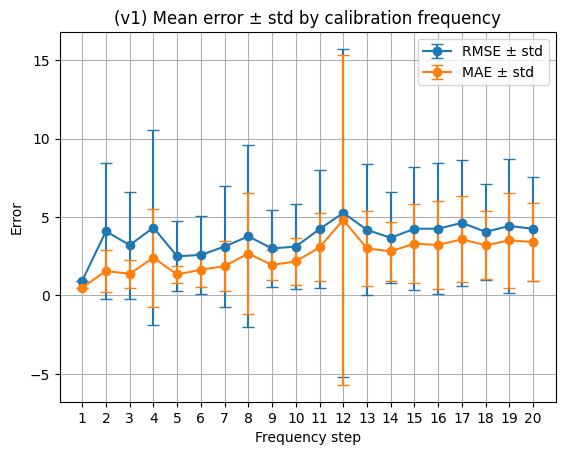

In [42]:
max_frequency = 20
frequency_results = []

for frequency in range(1, max_frequency + 1):
    offset_results = []

    for offset in range(frequency):
        df_data_filtered = (
            df_data
            .join(
                filter_calibration_frequency(
                    df_cal_times,
                    frequency=frequency,
                    offset=offset,
                ),
                on="datetime",
                how="left",
            )
            .with_columns(
                pl.col(["slope", "intercept"]).interpolate()
            )
            .with_columns(
                pl.col("slope")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),

                pl.col("intercept")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),
            )
            .with_columns(
                gmp343_dry_corrected=(
                    pl.col("gmp343_dry") * pl.col("slope")
                    + pl.col("intercept")
                )
            )
            .group_by_dynamic("datetime", every="1h")
            .agg(
                pl.col("gmp343_dry_corrected")
                .mean()
                .alias("gmp343_corrected")
            )
        )

        error = pl.col("ref_corrected") - pl.col("gmp343_corrected")

        metrics = (
            df_reference
            .join(df_data_filtered, on="datetime", how="left")
            .select(
                frequency=pl.lit(frequency).cast(pl.Int64),
                offset=pl.lit(offset).cast(pl.Int64),
                rmse=error.pow(2).mean().sqrt(),
                mae=error.abs().mean(),
            )
        )

        offset_results.append(metrics)

    df_offset_metrics = pl.concat(offset_results)

    frequency_metric = (
        df_offset_metrics
        .group_by("frequency")
        .agg(
            rmse_mean=pl.col("rmse").mean(),
            rmse_std=pl.col("rmse").std(),
            rmse_var=pl.col("rmse").var(),

            mae_mean=pl.col("mae").mean(),
            mae_std=pl.col("mae").std(),
            mae_var=pl.col("mae").var(),
        )
    )

    frequency_results.append(frequency_metric)

df_frequency_metrics = (
    pl.concat(frequency_results)
    .sort("frequency")
)

print(df_frequency_metrics)

# Plot mean RMSE and MAE with std error bars
plt.figure()

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["rmse_mean"].to_list(),
    yerr=df_frequency_metrics["rmse_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="RMSE ± std",
)

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["mae_mean"].to_list(),
    yerr=df_frequency_metrics["mae_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="MAE ± std",
)

plt.xticks(range(1, max_frequency + 1))

plt.xlabel("Frequency step")
plt.ylabel("Error")
plt.title("(v1) Mean error ± std by calibration frequency")
plt.legend()
plt.grid(True)
plt.show()

# v2

In [43]:
# define UTC timezones to filter the data to the time range of interest
start_time =  datetime(2025, 2, 18, 1, 0, 0).astimezone(timezone.utc)
end_time = datetime(2025, 10, 31, 0, 0, 0).astimezone(timezone.utc)

df_site = import_acropolis_site_data(target_directory=DESPIKED_DATA_DIRECTORY,
                                            deployment_times=deployment_times,
                                            site_name="TUMRv2") \
    .filter(pl.col("datetime").is_between(start_time, end_time))

# create a copy of the data to have a reference to compare to
df_reference = df_site.select(pl.col("datetime"), pl.col("gmp343_corrected"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U") \
    .group_by_dynamic("datetime", every="1h") \
    .agg(pl.col("gmp343_corrected").mean().alias("ref_corrected"))
    
# filter for slope, intercept; filter by first appearance of each unique value
df_cal_times = df_site.select(pl.col("datetime"), pl.col("slope"), pl.col("intercept")) \
    .unique(subset=["slope", "intercept"],keep="first",maintain_order=True)
    
# extract relevant data columns
df_data = df_site.select(pl.col("datetime"), pl.col("gmp343_dry"), pl.col("Flag")) \
    .filter(pl.col("Flag") == "U")

shape: (20, 7)
┌───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ frequency ┆ rmse_mean ┆ rmse_std ┆ rmse_var ┆ mae_mean ┆ mae_std  ┆ mae_var  │
│ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64       ┆ f64       ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 1         ┆ 0.931803  ┆ null     ┆ null     ┆ 0.499513 ┆ null     ┆ null     │
│ 2         ┆ 1.12511   ┆ 0.157136 ┆ 0.024692 ┆ 0.727024 ┆ 0.1497   ┆ 0.02241  │
│ 3         ┆ 1.176223  ┆ 0.153547 ┆ 0.023577 ┆ 0.830172 ┆ 0.125217 ┆ 0.015679 │
│ 4         ┆ 1.308136  ┆ 0.215373 ┆ 0.046385 ┆ 0.926831 ┆ 0.184107 ┆ 0.033895 │
│ 5         ┆ 1.440431  ┆ 0.28488  ┆ 0.081157 ┆ 1.072398 ┆ 0.23287  ┆ 0.054228 │
│ …         ┆ …         ┆ …        ┆ …        ┆ …        ┆ …        ┆ …        │
│ 16        ┆ 3.240438  ┆ 1.319112 ┆ 1.740056 ┆ 2.58412  ┆ 1.119825 ┆ 1.254007 │
│ 17        ┆

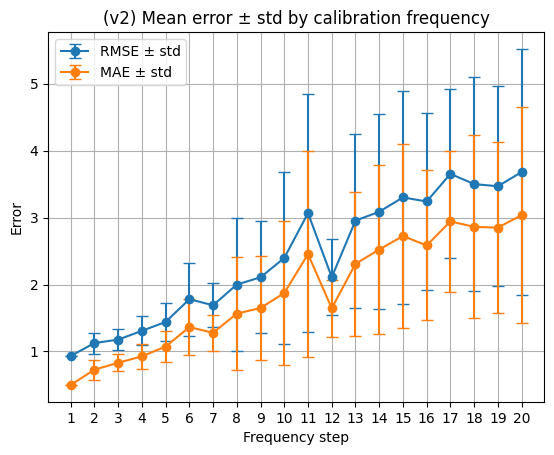

In [44]:
max_frequency = 20
frequency_results = []

for frequency in range(1, max_frequency + 1):
    offset_results = []

    for offset in range(frequency):
        df_data_filtered = (
            df_data
            .join(
                filter_calibration_frequency(
                    df_cal_times,
                    frequency=frequency,
                    offset=offset,
                ),
                on="datetime",
                how="left",
            )
            .with_columns(
                pl.col(["slope", "intercept"]).interpolate()
            )
            .with_columns(
                pl.col("slope")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),

                pl.col("intercept")
                .fill_null(strategy="forward")
                .fill_null(strategy="backward"),
            )
            .with_columns(
                gmp343_dry_corrected=(
                    pl.col("gmp343_dry") * pl.col("slope")
                    + pl.col("intercept")
                )
            )
            .group_by_dynamic("datetime", every="1h")
            .agg(
                pl.col("gmp343_dry_corrected")
                .mean()
                .alias("gmp343_corrected")
            )
        )

        error = pl.col("ref_corrected") - pl.col("gmp343_corrected")

        metrics = (
            df_reference
            .join(df_data_filtered, on="datetime", how="left")
            .select(
                frequency=pl.lit(frequency).cast(pl.Int64),
                offset=pl.lit(offset).cast(pl.Int64),
                rmse=error.pow(2).mean().sqrt(),
                mae=error.abs().mean(),
            )
        )

        offset_results.append(metrics)

    df_offset_metrics = pl.concat(offset_results)

    frequency_metric = (
        df_offset_metrics
        .group_by("frequency")
        .agg(
            rmse_mean=pl.col("rmse").mean(),
            rmse_std=pl.col("rmse").std(),
            rmse_var=pl.col("rmse").var(),

            mae_mean=pl.col("mae").mean(),
            mae_std=pl.col("mae").std(),
            mae_var=pl.col("mae").var(),
        )
    )

    frequency_results.append(frequency_metric)

df_frequency_metrics = (
    pl.concat(frequency_results)
    .sort("frequency")
)

print(df_frequency_metrics)

# Plot mean RMSE and MAE with std error bars
plt.figure()

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["rmse_mean"].to_list(),
    yerr=df_frequency_metrics["rmse_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="RMSE ± std",
)

plt.errorbar(
    df_frequency_metrics["frequency"].to_list(),
    df_frequency_metrics["mae_mean"].to_list(),
    yerr=df_frequency_metrics["mae_std"].fill_null(0).to_list(),
    marker="o",
    capsize=4,
    label="MAE ± std",
)

plt.xticks(range(1, max_frequency + 1))

plt.xlabel("Frequency step")
plt.ylabel("Error")
plt.title("(v2) Mean error ± std by calibration frequency")
plt.legend()
plt.grid(True)
plt.show()